# Sistema de Reconhecimento Facial

**Aluno:** Lucas  
**Disciplina:** Visão Computacional  

---

## Objetivos do Projeto

Este projeto implementa um sistema completo de verificação facial com três módulos:

| # | Módulo | Técnica |
|---|--------|---------|
| 1 | **Detector de Faces** | Viola-Jones (Haar Cascade) + DNN SSD (Caffe) |
| 2 | **Identificação de Faces** | LBPH — reconhece 'lucas' ou rejeita como 'desconhecido' |
| 3 | **Liveness Detection** | EAR (Eye Aspect Ratio) com 68 marcos faciais Dlib |

---

## Estrutura de Pastas

```
computer-vision/
├── fotos/
│   ├── lucas_1.jpg
│   ├── lucas_2.jpg
│   └── ...           (lucas_1 ate lucas_14)
├── classificadores/
│   └── haarcascade_frontalface_default.xml
└── modelos/
    ├── deploy.prototxt
    ├── res10_300x300_ssd_iter_140000.caffemodel
    └── shape_predictor_68_face_landmarks.dat
```

### Downloads necessários
- **Haar Cascade:** embutido no OpenCV (codigo usa automaticamente)
- **deploy.prototxt + caffemodel:** https://github.com/opencv/opencv_3rdparty/tree/dnn_samples_face_detector_20170830
- **shape_predictor_68:** http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2

---

## 1. Instalação e Importação de Bibliotecas

In [1]:
!pip uninstall opencv-python opencv-contrib-python opencv-python-headless -y
!pip install opencv-contrib-python

Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (79.2 MB)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Descomente e execute apenas se precisar instalar
# !pip install opencv-contrib-python dlib mediapipe scikit-learn scipy matplotlib numpy

import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import dlib
from scipy.spatial import distance as dist
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid', {'axes.grid': False})

print('Bibliotecas importadas com sucesso.')
print(f'OpenCV versao: {cv2.__version__}')

Bibliotecas importadas com sucesso.
OpenCV versao: 4.13.0


In [4]:
!pip install opencv-contrib-python --upgrade

## 2. Configuração de Caminhos

> Ajuste o `BASE_DIR` se necessário.

In [5]:
from google.colab import drive
import os

# Isso vai pedir permissão para acessar seus arquivos do Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
from google.colab import drive

# Isso vai pedir permissão para acessar o seu Drive
drive.mount('/content/drive')

# Caminho raiz no Colab (ajuste se a pasta 'computer-vision' estiver dentro de outra pasta no seu Drive)
BASE_DIR = '/content/drive/MyDrive/computer-vision'

FOTOS_DIR        = os.path.join(BASE_DIR, 'fotos')
CLASSIF_DIR      = os.path.join(BASE_DIR, 'classificadores')
MODELOS_DIR      = os.path.join(BASE_DIR, 'modelos')
MODELO_LBPH_PATH = os.path.join(BASE_DIR, 'modelo_lbph.yml')

# Parâmetros do sistema continuam iguais...
PESSOA_AUTORIZADA = 'lucas'
LIMIAR_LBPH       = 80
EAR_LIMIAR        = 0.25
FRAMES_PISCADA    = 2
PISCADAS_MINIMAS  = 1

print('Pastas configuradas!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pastas configuradas!


In [7]:
import os

# O caminho padrão do Google Drive no Colab é este:
BASE_DIR = '/content/drive/MyDrive/computer-vision'

FOTOS_DIR        = os.path.join(BASE_DIR, 'fotos')
CLASSIF_DIR      = os.path.join(BASE_DIR, 'classificadores')
MODELOS_DIR      = os.path.join(BASE_DIR, 'modelos')
MODELO_LBPH_PATH = os.path.join(BASE_DIR, 'modelo_lbph.yml')

# Parametros do sistema
PESSOA_AUTORIZADA = 'lucas'

print('Verificando pastas no Google Drive:')
for d in [FOTOS_DIR, CLASSIF_DIR, MODELOS_DIR]:
    if os.path.exists(d):
        print(f'  [OK]  {d}')
    else:
        print(f'  [NAO ENCONTRADO]  {d}')
        # Opcional: Criar a pasta se não existir
        # os.makedirs(d)
        # print(f'  [CRIADO] {d}')

# Verificação de fotos
if os.path.exists(FOTOS_DIR):
    fotos_lista = [f for f in os.listdir(FOTOS_DIR)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f'\nFotos encontradas: {len(fotos_lista)}')
else:
    print(f'\n[ERRO] Diretorio de fotos nao existe no Drive: {FOTOS_DIR}')

print(f'Pessoa autorizada: {PESSOA_AUTORIZADA}')

Verificando pastas no Google Drive:
  [OK]  /content/drive/MyDrive/computer-vision/fotos
  [NAO ENCONTRADO]  /content/drive/MyDrive/computer-vision/classificadores
  [NAO ENCONTRADO]  /content/drive/MyDrive/computer-vision/modelos

Fotos encontradas: 13
Pessoa autorizada: lucas


---
# MODULO 1 — DETECCAO DE FACES

### Metodos implementados:
- **Viola-Jones (Haar Cascade):** classico, rapido, menor que 0.02s por frame, ideal para tempo real
- **DNN SSD (Caffe):** baseado em deep learning, mais robusto a variacoes de angulo e iluminacao

**Referencia:** Viola & Jones (2001) — https://www.cs.cmu.edu/~efros/courses/LBMV07/Papers/viola-cvpr-01.pdf

In [8]:
# Carrega Haar Cascade
haar_path = os.path.join(CLASSIF_DIR, 'haarcascade_frontalface_default.xml')
if not os.path.exists(haar_path):
    haar_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    print('Usando Haar Cascade embutido do OpenCV.')

classificador_haar = cv2.CascadeClassifier(haar_path)

# Carrega DNN SSD
prototxt_path   = os.path.join(MODELOS_DIR, 'deploy.prototxt')
caffemodel_path = os.path.join(MODELOS_DIR, 'res10_300x300_ssd_iter_140000.caffemodel')

modelo_dnn = None
if os.path.exists(prototxt_path) and os.path.exists(caffemodel_path):
    modelo_dnn = cv2.dnn.readNetFromCaffe(prototxt_path, caffemodel_path)
    print('Modelo DNN SSD carregado.')
else:
    print('Modelo DNN nao encontrado. Usando somente Haar Cascade.')


def detectar_faces_haar(imagem_bgr, scale=1.3, min_neighbors=5):
    """
    Detecta faces usando Viola-Jones (Haar Cascade).

    Parametros:
    - imagem_bgr: imagem no formato BGR
    - scale: fator de reducao de escala a cada iteracao (padrao 1.3)
    - min_neighbors: minimo de vizinhos para validar uma deteccao (padrao 5)

    Retorna:
    - imagem_rgb anotada com retangulos
    - lista de faces [(x, y, w, h)]
    """
    img_rgb  = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2GRAY)
    out      = img_rgb.copy()
    faces    = classificador_haar.detectMultiScale(img_gray, scale, min_neighbors)

    if len(faces) == 0:
        cv2.putText(out, 'Nenhum rosto detectado', (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (220, 50, 50), 2)
    for (x, y, w, h) in faces:
        cv2.rectangle(out, (x, y), (x+w, y+h), (255, 215, 0), 2)
        cv2.putText(out, 'Face', (x, y-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 215, 0), 2)
    return out, faces


def detectar_faces_dnn(imagem_bgr, confianca_min=0.5):
    """
    Detecta faces usando DNN SSD (Caffe).

    Parametros:
    - imagem_bgr: imagem no formato BGR
    - confianca_min: limiar minimo de confianca para aceitar deteccao (padrao 0.5)

    Retorna:
    - imagem_rgb anotada com confianca percentual
    - lista de boxes [(x, y, w, h)]
    """
    if modelo_dnn is None:
        return cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB), []

    img_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)
    out     = img_rgb.copy()
    (h, w)  = imagem_bgr.shape[:2]
    blob    = cv2.dnn.blobFromImage(cv2.resize(imagem_bgr, (300, 300)),
                                     1.0, (300, 300), (104.0, 177.0, 123.0))
    modelo_dnn.setInput(blob)
    dets  = modelo_dnn.forward()
    boxes = []

    for i in range(dets.shape[2]):
        conf = dets[0, 0, i, 2]
        if conf > confianca_min:
            box = dets[0, 0, i, 3:7] * np.array([w, h, w, h])
            (x1, y1, x2, y2) = box.astype('int')
            boxes.append((x1, y1, x2-x1, y2-y1))
            cv2.rectangle(out, (x1, y1), (x2, y2), (0, 200, 120), 2)
            cv2.putText(out, f'{conf*100:.1f}%', (x1, y1-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 200, 120), 2)

    if len(boxes) == 0:
        cv2.putText(out, 'Nenhum rosto detectado', (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (220, 50, 50), 2)
    return out, boxes


print('Funcoes de deteccao configuradas.')

Usando Haar Cascade embutido do OpenCV.
Modelo DNN nao encontrado. Usando somente Haar Cascade.
Funcoes de deteccao configuradas.


In [9]:
# Visualizacao: todas as fotos com deteccao Haar
fotos_lista = sorted([f for f in os.listdir(FOTOS_DIR)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

cols = 4
rows = (len(fotos_lista) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = np.array(axes).ravel()

for i, foto in enumerate(fotos_lista):
    img_bgr = cv2.imread(os.path.join(FOTOS_DIR, foto))
    img_ann, faces = detectar_faces_haar(img_bgr)
    axes[i].imshow(img_ann)
    axes[i].set_title(f'{foto}\n{len(faces)} face(s)', fontsize=9)
    axes[i].axis('off')

for j in range(len(fotos_lista), len(axes)):
    axes[j].axis('off')

plt.suptitle('Modulo 1 — Deteccao com Viola-Jones (Haar Cascade)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

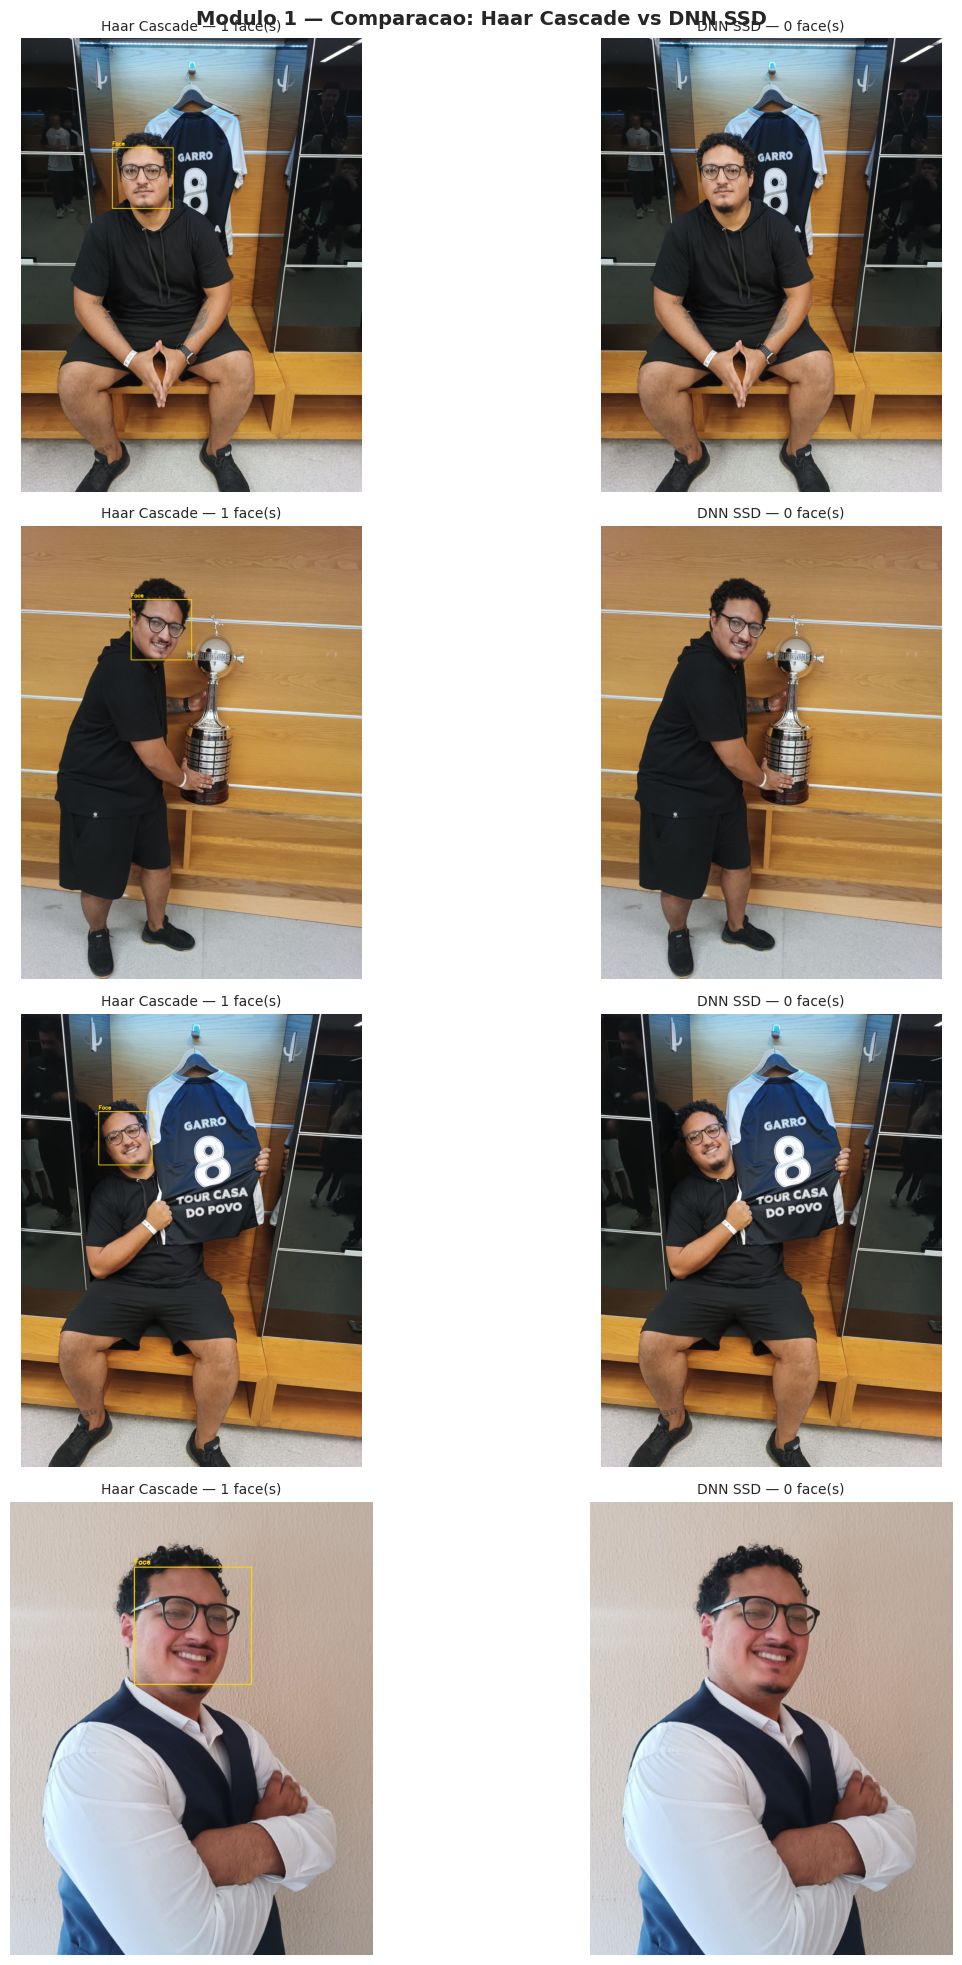

In [10]:
# Comparacao Haar vs DNN nas primeiras 4 fotos
n = min(4, len(fotos_lista))
fig, axes = plt.subplots(n, 2, figsize=(14, 5 * n))

for i in range(n):
    img_bgr = cv2.imread(os.path.join(FOTOS_DIR, fotos_lista[i]))

    img_h, fh = detectar_faces_haar(img_bgr)
    img_d, fd = detectar_faces_dnn(img_bgr)

    axes[i][0].imshow(img_h)
    axes[i][0].set_title(f'Haar Cascade — {len(fh)} face(s)', fontsize=10)
    axes[i][0].axis('off')

    axes[i][1].imshow(img_d)
    axes[i][1].set_title(f'DNN SSD — {len(fd)} face(s)', fontsize=10)
    axes[i][1].axis('off')

plt.suptitle('Modulo 1 — Comparacao: Haar Cascade vs DNN SSD',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# MODULO 2 — IDENTIFICACAO DE FACES (LBPH)

### Cenario: pessoa autorizada vs desconhecido

- **Treino:** aprende o padrao visual do Lucas com as 14 fotos
- **Inferencia:** confianca LBPH abaixo do limiar -> **LUCAS** (autorizado)
- **Inferencia:** confianca LBPH acima do limiar -> **DESCONHECIDO** (rejeitado)

> No LBPH, **menor confianca = mais parecido com o modelo treinado**.

### Como o LBPH funciona:
1. Para cada pixel, compara com os 8 vizinhos e gera um codigo binario
2. Divide a face em celulas (grid 8x8 por padrao)
3. Calcula um histograma de textura por celula
4. Concatena todos os histogramas em um vetor de features da face
5. Na predicao, calcula a distancia entre histogramas

In [11]:
def extrair_roi_face(img_bgr, tamanho=(100, 100)):
    """
    Detecta a face principal e retorna a ROI em escala de cinza.
    Se nenhuma face for detectada, usa a imagem inteira redimensionada.
    """
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, faces = detectar_faces_haar(img_bgr)

    if len(faces) > 0:
        (x, y, w, h) = faces[0]
        roi = img_gray[y:y+h, x:x+w]
    else:
        roi = img_gray

    return cv2.resize(roi, tamanho)


def carregar_dataset(pasta):
    """
    Carrega todas as imagens e prepara o dataset para o LBPH.
    Convencao: 'lucas_1.jpg' -> label = 'lucas' -> ID numerico 0

    Retorna:
    - faces: lista de ROIs em escala de cinza (100x100)
    - labels: array de IDs numericos
    - label_para_nome: dicionario {id: nome}
    - nome_para_label: dicionario {nome: id}
    """
    faces, labels   = [], []
    label_para_nome = {}
    nome_para_label = {}
    contador        = 0

    arquivos = sorted([f for f in os.listdir(pasta)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

    print(f'Carregando {len(arquivos)} imagens...')

    for arq in arquivos:
        nome = os.path.splitext(arq)[0].split('_')[0].lower()

        if nome not in nome_para_label:
            nome_para_label[nome]    = contador
            label_para_nome[contador] = nome
            contador += 1

        img_bgr = cv2.imread(os.path.join(pasta, arq))
        if img_bgr is None:
            print(f'  Erro ao carregar: {arq}')
            continue

        roi = extrair_roi_face(img_bgr)
        faces.append(roi)
        labels.append(nome_para_label[nome])

    print(f'Dataset pronto.')
    print(f'  Total de amostras : {len(faces)}')
    print(f'  Pessoas           : {list(nome_para_label.keys())}')

    return faces, np.array(labels), label_para_nome, nome_para_label


faces, labels, label_para_nome, nome_para_label = carregar_dataset(FOTOS_DIR)

Carregando 13 imagens...
Dataset pronto.
  Total de amostras : 13
  Pessoas           : ['lucas']


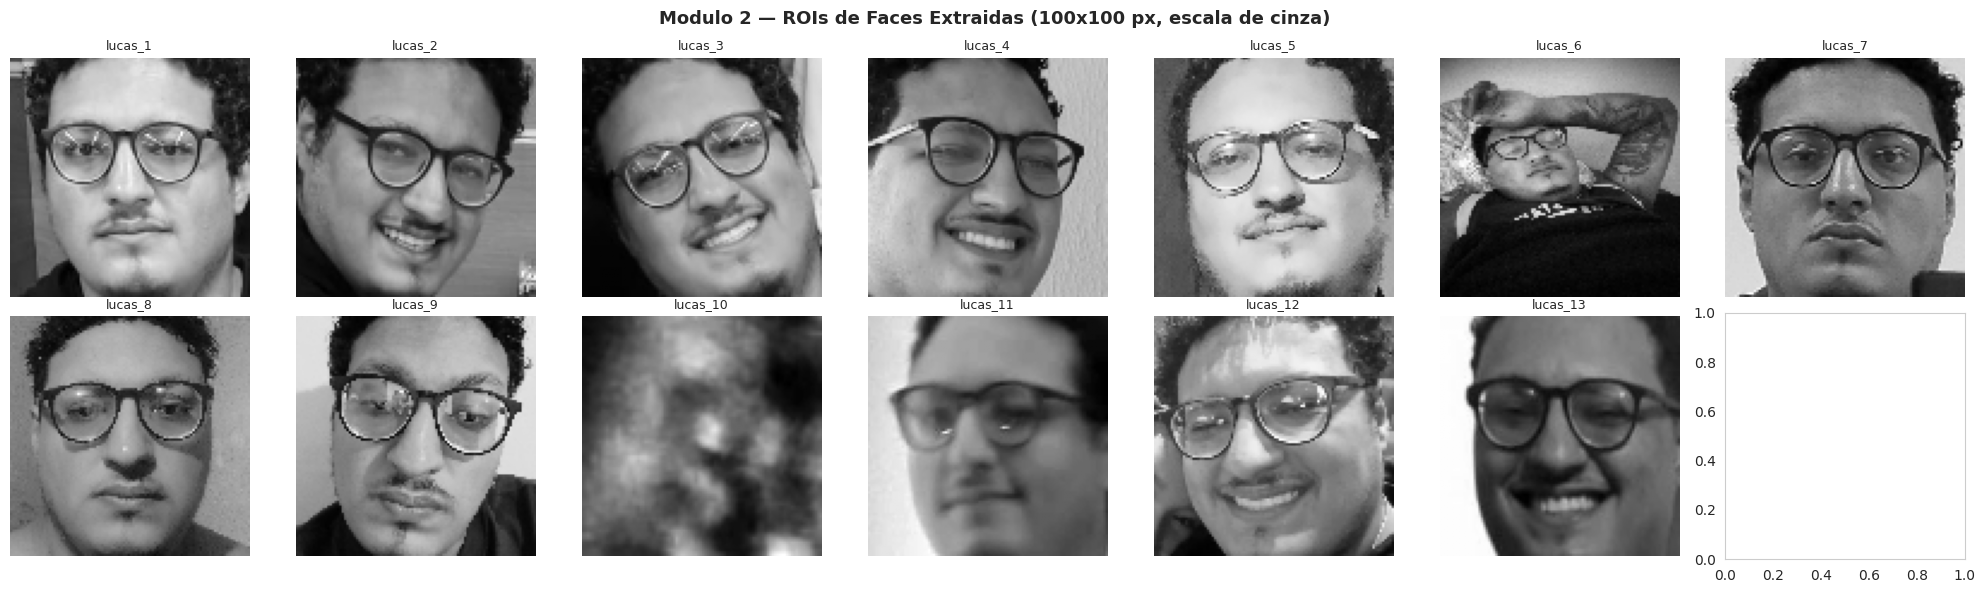

In [12]:
# Visualizar as ROIs extraidas
fig, axes = plt.subplots(2, 7, figsize=(20, 6))
axes = axes.ravel()

for i in range(min(14, len(faces))):
    axes[i].imshow(faces[i], cmap='gray')
    axes[i].set_title(f'{label_para_nome[labels[i]]}_{i+1}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Modulo 2 — ROIs de Faces Extraidas (100x100 px, escala de cinza)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Split 80% treino / 20% teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    faces, labels, test_size=0.20, random_state=42
)

print('Split do dataset:')
print(f'  Treino : {len(X_treino)} amostras ({len(X_treino)/len(faces)*100:.0f}%)')
print(f'  Teste  : {len(X_teste)} amostras ({len(X_teste)/len(faces)*100:.0f}%)')

# Treina o reconhecedor LBPH
# radius=1: raio do LBP
# neighbors=8: pontos ao redor de cada pixel
# grid_x, grid_y: divisao da imagem em celulas
reconhecedor_lbph = cv2.face.LBPHFaceRecognizer_create(
    radius=1, neighbors=8, grid_x=8, grid_y=8
)

print('\nTreinando reconhecedor LBPH...')
reconhecedor_lbph.train(X_treino, y_treino)
reconhecedor_lbph.save(MODELO_LBPH_PATH)
print(f'Modelo treinado e salvo em: {MODELO_LBPH_PATH}')

Split do dataset:
  Treino : 10 amostras (77%)
  Teste  : 3 amostras (23%)

Treinando reconhecedor LBPH...
Modelo treinado e salvo em: /content/drive/MyDrive/computer-vision/modelo_lbph.yml


In [14]:
# Avaliacao no conjunto de teste
y_pred     = []
confianças = []
nomes_pred = []

for img in X_teste:
    label_id, conf = reconhecedor_lbph.predict(img)
    y_pred.append(label_id)
    confianças.append(conf)
    nomes_pred.append(label_para_nome[label_id] if conf <= LIMIAR_LBPH else 'desconhecido')

nomes_reais = [label_para_nome[l] for l in y_teste]
acuracia    = accuracy_score(nomes_reais, nomes_pred)

print('Resultados do Modulo 2 — Identificacao LBPH')
print(f'  Acuracia no teste       : {acuracia * 100:.1f}%')
print(f'  Limiar de rejeicao      : {LIMIAR_LBPH} (confianca LBPH)')
print(f'  Confianca media (teste) : {np.mean(confianças):.2f}')
print(f'  Menor confianca         : {np.min(confianças):.2f}  (mais parecido)')
print(f'  Maior confianca         : {np.max(confianças):.2f}  (menos parecido)')
print()
print('Detalhes por imagem de teste:')
for i in range(len(X_teste)):
    ok = 'OK' if nomes_reais[i] == nomes_pred[i] else 'ERRO'
    print(f'  [{ok}] Real: {nomes_reais[i]:15s} | Previsto: {nomes_pred[i]:15s} | Confianca: {confianças[i]:.2f}')

Resultados do Modulo 2 — Identificacao LBPH
  Acuracia no teste       : 0.0%
  Limiar de rejeicao      : 80 (confianca LBPH)
  Confianca media (teste) : 106.71
  Menor confianca         : 85.53  (mais parecido)
  Maior confianca         : 125.52  (menos parecido)

Detalhes por imagem de teste:
  [ERRO] Real: lucas           | Previsto: desconhecido    | Confianca: 109.09
  [ERRO] Real: lucas           | Previsto: desconhecido    | Confianca: 125.52
  [ERRO] Real: lucas           | Previsto: desconhecido    | Confianca: 85.53


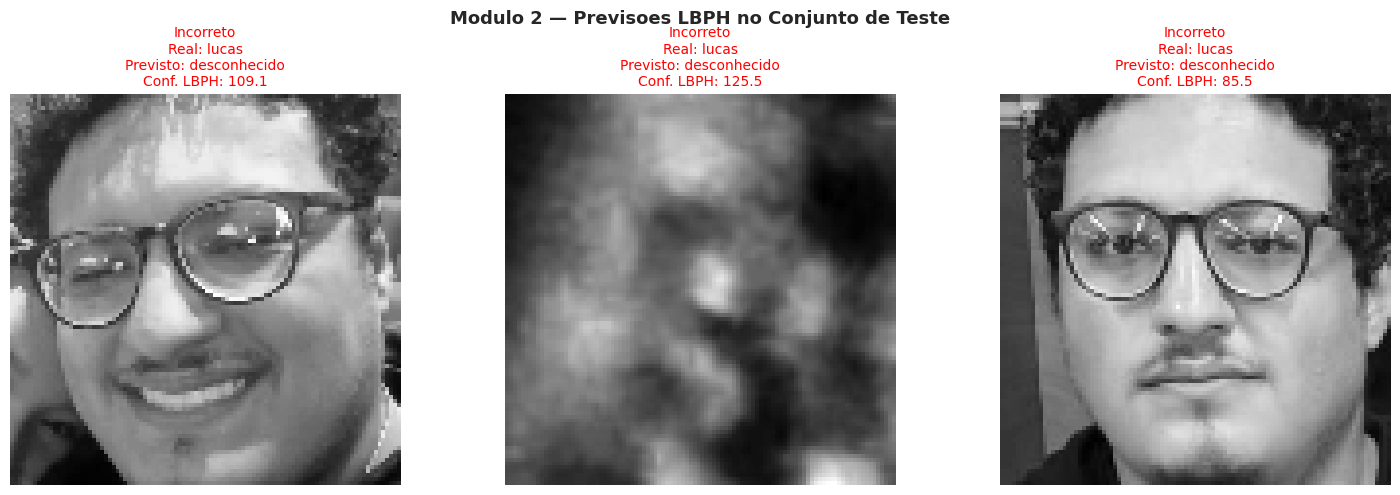

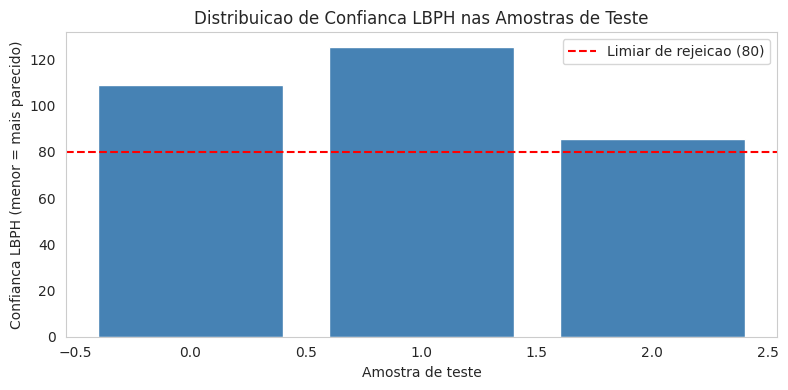

In [15]:
# Visualizar previsoes com confianca
n   = len(X_teste)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

if n == 1:
    axes = [axes]

for i in range(n):
    correto = nomes_reais[i] == nomes_pred[i]
    cor     = 'green' if correto else 'red'
    status  = 'Correto' if correto else 'Incorreto'

    axes[i].imshow(X_teste[i], cmap='gray')
    axes[i].set_title(
        f'{status}\nReal: {nomes_reais[i]}\nPrevisto: {nomes_pred[i]}\nConf. LBPH: {confianças[i]:.1f}',
        color=cor, fontsize=10
    )
    axes[i].axis('off')

plt.suptitle('Modulo 2 — Previsoes LBPH no Conjunto de Teste',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Grafico de distribuicao de confianca
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(confianças)), confianças, color='steelblue', edgecolor='white')
ax.axhline(LIMIAR_LBPH, color='red', linestyle='--', linewidth=1.5,
           label=f'Limiar de rejeicao ({LIMIAR_LBPH})')
ax.set_xlabel('Amostra de teste')
ax.set_ylabel('Confianca LBPH (menor = mais parecido)')
ax.set_title('Distribuicao de Confianca LBPH nas Amostras de Teste')
ax.legend()
plt.tight_layout()
plt.show()

---
# MODULO 3 — DETECCAO DE VIVACIDADE (LIVENESS)

## Por que e necessario?

Sem liveness, um fraudador pode apresentar uma foto impressa do Lucas e enganar o LBPH.  
O sistema de liveness garante que ha uma pessoa real e viva na camera.

## Tecnica: EAR (Eye Aspect Ratio)

Usando os 68 marcos faciais do Dlib, calculamos a proporcao de abertura de cada olho.

```
        p2    p3
   p1 ──────────── p4
        p6    p5

EAR = (||p2-p6|| + ||p3-p5||) / (2 x ||p1-p4||)
```

| EAR | Estado |
|-----|--------|
| ~0.30 | Olho aberto |
| ~0.10 | Olho fechado (piscada) |

**Criterio de aprovacao:**  
EAR cai abaixo de 0.25 por 2 ou mais frames consecutivos -> piscada detectada -> VIVO

**Referencia:** Soukupova & Cech, *Real-Time Eye Blink Detection using Facial Landmarks*, 2016

In [16]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bzip2 -d shape_predictor_68_face_landmarks.dat.bz2

--2026-03-30 18:12:54--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-03-30 18:12:55--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2.3’

shape_predictor_68_ 100%[===================>]  61.07M  47.5MB/s    in 1.3s    

2026-03-30 18:12:56 (47.5 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2.3’ saved [64040097/64040097]

bzip2: Output file shape_predictor_68_face_landmarks.dat already exists.


In [17]:
import os
print(os.path.exists('/content/shape_predictor_68_face_landmarks.dat'))

True


In [18]:
# Carrega Dlib
LANDMARKS_PATH = '/content/shape_predictor_68_face_landmarks.dat'

DLIB_OK = False
if os.path.exists(LANDMARKS_PATH):
    detector_dlib   = dlib.get_frontal_face_detector()
    preditor_marcos = dlib.shape_predictor(LANDMARKS_PATH)
    DLIB_OK = True
    print('Modelo de 68 marcos Dlib carregado.')
else:
    print('shape_predictor_68_face_landmarks.dat nao encontrado.')
    print(f'Esperado em: {LANDMARKS_PATH}')
    print('Baixe em: http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2')

# Indices dos olhos nos 68 marcos (base zero, conforme Dlib)
IDX_OLHO_DIR = list(range(36, 42))   # pontos 37-42
IDX_OLHO_ESQ = list(range(42, 48))   # pontos 43-48


def calcular_ear(pontos):
    """
    Calcula Eye Aspect Ratio (EAR).

    Baseado em: Soukupova & Cech (2016)
    http://vision.fe.uni-lj.si/cvww2016/proceedings/papers/05.pdf

    Parametros:
    - pontos: lista de 6 tuplas (x, y) representando o olho

    Retorna:
    - valor EAR (float). Quanto menor, mais fechado o olho.
    """
    A = dist.euclidean(pontos[1], pontos[5])
    B = dist.euclidean(pontos[2], pontos[4])
    C = dist.euclidean(pontos[0], pontos[3])
    return (A + B) / (2.0 * C)


def pontos_olho(shape, indices):
    """Extrai coordenadas (x, y) de um olho a partir do shape Dlib."""
    return [(shape.part(i).x, shape.part(i).y) for i in indices]


def analisar_frame_liveness(img_bgr):
    """
    Analisa um frame e retorna o EAR medio dos dois olhos.

    Retorna:
    - imagem_rgb anotada com marcos faciais e valor EAR
    - ear_medio (float) ou None se nenhuma face detectada
    """
    if not DLIB_OK:
        return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), None

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    out      = img_rgb.copy()
    dets     = detector_dlib(img_gray, 1)

    if len(dets) == 0:
        cv2.putText(out, 'Sem face', (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (220, 50, 50), 2)
        return out, None

    ear_lista = []
    for det in dets:
        shape = preditor_marcos(img_gray, det)

        pt_dir = pontos_olho(shape, IDX_OLHO_DIR)
        pt_esq = pontos_olho(shape, IDX_OLHO_ESQ)

        ear_dir = calcular_ear(pt_dir)
        ear_esq = calcular_ear(pt_esq)
        ear_med = (ear_dir + ear_esq) / 2.0
        ear_lista.append(ear_med)

        # Contorno dos olhos
        for pts in [pt_dir, pt_esq]:
            hull = cv2.convexHull(np.array(pts))
            cv2.drawContours(out, [hull], -1, (0, 220, 180), 1)

        # Todos os 68 marcos
        for i in range(68):
            cv2.circle(out, (shape.part(i).x, shape.part(i).y), 2, (255, 160, 0), -1)

        # EAR na imagem
        status = 'FECHADO' if ear_med < EAR_LIMIAR else 'ABERTO'
        cor    = (50, 200, 50) if ear_med >= EAR_LIMIAR else (220, 50, 50)
        cv2.putText(out, f'EAR: {ear_med:.3f} [{status}]',
                    (det.left(), det.top() - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, cor, 2)

    return out, float(np.mean(ear_lista))


print('Funcoes de Liveness (EAR) configuradas.')

Modelo de 68 marcos Dlib carregado.
Funcoes de Liveness (EAR) configuradas.


In [19]:
# Analise EAR em todas as fotos
if DLIB_OK:
    cols = 4
    rows = (len(fotos_lista) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes = np.array(axes).ravel()

    ear_por_foto = {}

    for i, foto in enumerate(fotos_lista):
        img_bgr = cv2.imread(os.path.join(FOTOS_DIR, foto))
        img_ann, ear = analisar_frame_liveness(img_bgr)
        ear_por_foto[foto] = ear

        status = ''
        if ear is not None:
            status = 'FECHADO' if ear < EAR_LIMIAR else 'ABERTO'
        axes[i].imshow(img_ann)
        axes[i].set_title(
            f'{foto}\nEAR: {ear:.3f} — {status}' if ear else foto,
            fontsize=8
        )
        axes[i].axis('off')

    for j in range(len(fotos_lista), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Modulo 3 — Analise EAR por Frame (limiar = {EAR_LIMIAR})',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Dlib nao disponivel. Instale o shape_predictor.')

Output hidden; open in https://colab.research.google.com to view.

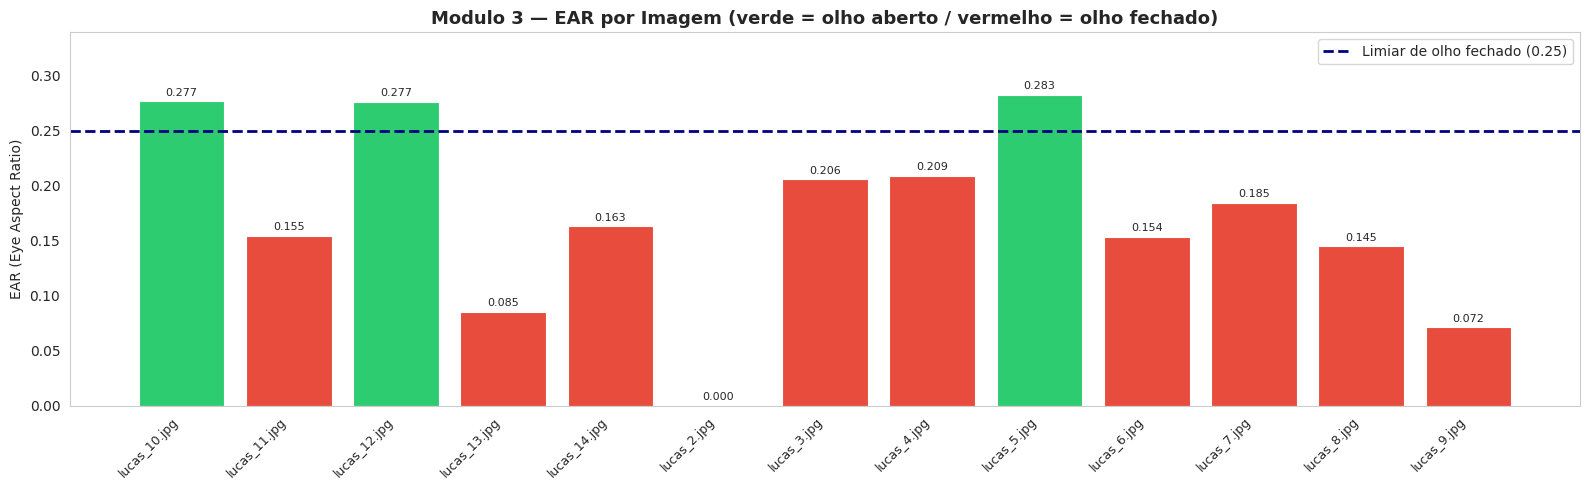

Resumo EAR:
  Frames com olho aberto  : 3
  Frames com olho fechado : 10
  EAR medio geral         : 0.1700
  EAR minimo              : 0.0000
  EAR maximo              : 0.2830


In [20]:
# Grafico de EAR por foto
if DLIB_OK and ear_por_foto:
    fotos_ord = list(ear_por_foto.keys())
    ear_vals  = [ear_por_foto[f] if ear_por_foto[f] is not None else 0 for f in fotos_ord]

    cores = ['#e74c3c' if e < EAR_LIMIAR else '#2ecc71' for e in ear_vals]

    fig, ax = plt.subplots(figsize=(16, 5))
    bars = ax.bar(range(len(fotos_ord)), ear_vals, color=cores, edgecolor='white', linewidth=0.8)
    ax.axhline(EAR_LIMIAR, color='navy', linestyle='--', linewidth=2,
               label=f'Limiar de olho fechado ({EAR_LIMIAR})')

    ax.set_xticks(range(len(fotos_ord)))
    ax.set_xticklabels(fotos_ord, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('EAR (Eye Aspect Ratio)')
    ax.set_title('Modulo 3 — EAR por Imagem (verde = olho aberto / vermelho = olho fechado)',
                 fontsize=13, fontweight='bold')
    ax.legend()
    ax.set_ylim(0, max(ear_vals) * 1.2 if max(ear_vals) > 0 else 0.5)

    for bar, val in zip(bars, ear_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()

    fechados = sum(1 for e in ear_vals if e < EAR_LIMIAR)
    print('Resumo EAR:')
    print(f'  Frames com olho aberto  : {len(ear_vals) - fechados}')
    print(f'  Frames com olho fechado : {fechados}')
    print(f'  EAR medio geral         : {np.mean(ear_vals):.4f}')
    print(f'  EAR minimo              : {np.min(ear_vals):.4f}')
    print(f'  EAR maximo              : {np.max(ear_vals):.4f}')

In [21]:
def detectar_liveness(caminhos_frames,
                       ear_limiar=EAR_LIMIAR,
                       frames_min=FRAMES_PISCADA,
                       piscadas_min=PISCADAS_MINIMAS):
    """
    Detecta vivacidade analisando uma sequencia de frames.

    Logica:
    - EAR cai abaixo do limiar por `frames_min` frames consecutivos -> piscada
    - Se total de piscadas >= `piscadas_min` -> APROVADO

    Parametros:
    - caminhos_frames: lista de caminhos das imagens (ou frames de video)
    - ear_limiar: EAR abaixo do qual o olho e considerado fechado
    - frames_min: minimo de frames consecutivos para contar como piscada
    - piscadas_min: minimo de piscadas para aprovar liveness

    Retorna:
    - resultado (str)
    - total_piscadas (int)
    - historico_ear (list)
    """
    if not DLIB_OK:
        return 'INDETERMINADO (Dlib ausente)', 0, []

    contador_olho_fech = 0
    total_piscadas     = 0
    historico_ear      = []

    for caminho in caminhos_frames:
        img_bgr = cv2.imread(caminho)
        if img_bgr is None:
            continue
        _, ear = analisar_frame_liveness(img_bgr)

        if ear is None:
            contador_olho_fech = 0
            historico_ear.append(None)
            continue

        historico_ear.append(ear)

        if ear < ear_limiar:
            contador_olho_fech += 1
        else:
            if contador_olho_fech >= frames_min:
                total_piscadas    += 1
                print(f'  Piscada #{total_piscadas} detectada. EAR subiu de abaixo de {ear_limiar} para {ear:.3f}')
            contador_olho_fech = 0

    resultado = 'APROVADO — pessoa viva' if total_piscadas >= piscadas_min else 'REPROVADO — possivel fraude por foto estatica'
    return resultado, total_piscadas, historico_ear


# Executa com as 14 fotos como sequencia simulada
frames = [os.path.join(FOTOS_DIR, f) for f in sorted(fotos_lista)]

print('Analisando liveness na sequencia de imagens...')
print(f'  Configuracao: EAR limiar={EAR_LIMIAR}, frames minimos={FRAMES_PISCADA}\n')

resultado_lv, n_piscadas, hist_ear = detectar_liveness(frames)

print()
print('=' * 55)
print(f'  RESULTADO LIVENESS: {resultado_lv}')
print(f'  Piscadas detectadas: {n_piscadas}')
print('=' * 55)

Analisando liveness na sequencia de imagens...
  Configuracao: EAR limiar=0.25, frames minimos=2

  Piscada #1 detectada. EAR subiu de abaixo de 0.25 para 0.283

  RESULTADO LIVENESS: APROVADO — pessoa viva
  Piscadas detectadas: 1


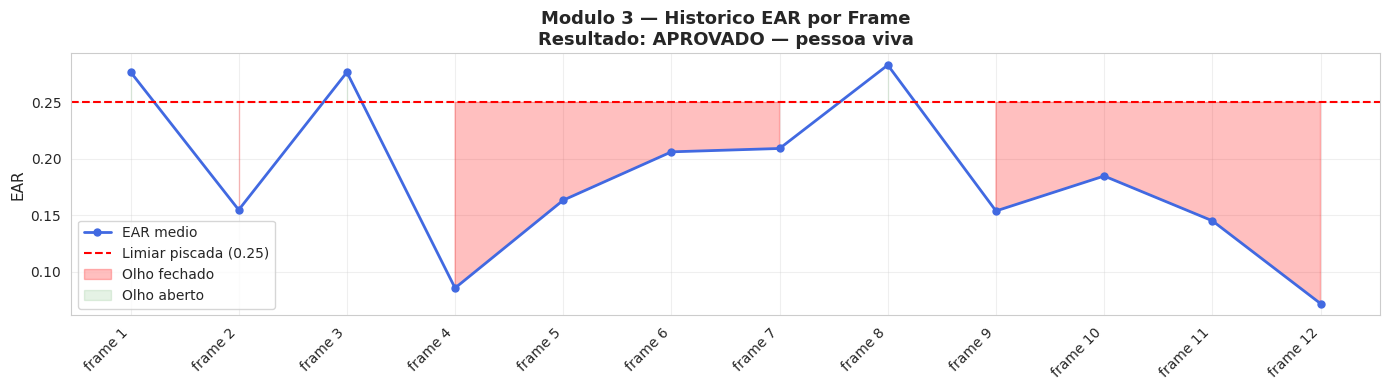

In [22]:
# Grafico do historico EAR da sequencia
ear_seq = [e for e in hist_ear if e is not None]

if ear_seq:
    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(ear_seq, color='royalblue', linewidth=2, marker='o', markersize=5, label='EAR medio')
    ax.axhline(EAR_LIMIAR, color='red', linestyle='--', linewidth=1.5,
               label=f'Limiar piscada ({EAR_LIMIAR})')
    ax.fill_between(range(len(ear_seq)), ear_seq, EAR_LIMIAR,
                    where=[e < EAR_LIMIAR for e in ear_seq],
                    alpha=0.25, color='red', label='Olho fechado')
    ax.fill_between(range(len(ear_seq)), ear_seq, EAR_LIMIAR,
                    where=[e >= EAR_LIMIAR for e in ear_seq],
                    alpha=0.1, color='green', label='Olho aberto')

    ax.set_xticks(range(len(ear_seq)))
    ax.set_xticklabels([f'frame {i+1}' for i in range(len(ear_seq))], rotation=45, ha='right')
    ax.set_ylabel('EAR', fontsize=11)
    ax.set_title(f'Modulo 3 — Historico EAR por Frame\nResultado: {resultado_lv}',
                 fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---
# PIPELINE COMPLETO — Os 3 Modulos Integrados

In [23]:
def verificar_identidade_completo(caminho_imagem):
    """
    Pipeline completo de verificacao facial:
      1. Detecta face (Haar Cascade)
      2. Identifica pessoa (LBPH)
      3. Analisa liveness (EAR — indicativo em frame unico)

    Parametros:
    - caminho_imagem: caminho para a imagem de entrada

    Retorna:
    - dicionario com os resultados de cada modulo
    """
    img_bgr = cv2.imread(caminho_imagem)
    if img_bgr is None:
        return {'erro': f'Imagem nao encontrada: {caminho_imagem}'}

    resultado = {'arquivo': os.path.basename(caminho_imagem)}

    # Modulo 1: Deteccao
    _, faces = detectar_faces_haar(img_bgr)
    resultado['faces_detectadas'] = len(faces)

    # Modulo 2: Identificacao
    if len(faces) > 0:
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        (x, y, w, h) = faces[0]
        roi = cv2.resize(img_gray[y:y+h, x:x+w], (100, 100))

        label_id, conf = reconhecedor_lbph.predict(roi)
        nome = label_para_nome.get(label_id, 'desconhecido')
        if conf > LIMIAR_LBPH:
            nome = 'desconhecido'

        resultado['identidade']     = nome
        resultado['confianca_lbph'] = round(conf, 2)
        resultado['autorizado']     = nome == PESSOA_AUTORIZADA
    else:
        resultado['identidade']     = 'N/A'
        resultado['confianca_lbph'] = None
        resultado['autorizado']     = False

    # Modulo 3: Liveness
    _, ear = analisar_frame_liveness(img_bgr)
    resultado['ear']         = round(ear, 4) if ear else None
    resultado['olho_status'] = ('ABERTO'  if ear and ear >= EAR_LIMIAR
                                else 'FECHADO' if ear else 'N/A')

    return resultado


# Executa o pipeline em todas as fotos
print('=' * 70)
print('  PIPELINE COMPLETO — Resultados por Imagem')
print('=' * 70)
print(f'  {"ARQUIVO":<15} {"FACES":>5} {"IDENTIDADE":<15} {"CONF":>7} {"AUTOR.":>8} {"EAR":>7} {"OLHO":<8}')
print('-' * 70)

for foto in sorted(fotos_lista):
    r    = verificar_identidade_completo(os.path.join(FOTOS_DIR, foto))
    aut  = 'SIM' if r.get('autorizado') else 'NAO'
    conf = f"{r['confianca_lbph']:.1f}" if r['confianca_lbph'] is not None else 'N/A'
    ear  = f"{r['ear']:.3f}" if r['ear'] is not None else 'N/A'
    print(f"  {r['arquivo']:<15} {r['faces_detectadas']:>5} {r['identidade']:<15} {conf:>7} {aut:>8} {ear:>7} {r['olho_status']:<8}")

  PIPELINE COMPLETO — Resultados por Imagem
  ARQUIVO         FACES IDENTIDADE         CONF   AUTOR.     EAR OLHO    
----------------------------------------------------------------------
  lucas_10.jpg        1 desconhecido       85.5      NAO   0.277 ABERTO  
  lucas_11.jpg        1 lucas               0.0      SIM   0.155 FECHADO 
  lucas_12.jpg        1 lucas               0.0      SIM   0.277 ABERTO  
  lucas_13.jpg        1 lucas               0.0      SIM   0.085 FECHADO 
  lucas_14.jpg        1 lucas               0.0      SIM   0.163 FECHADO 
  lucas_2.jpg         0 N/A                 N/A      NAO     N/A N/A     
  lucas_3.jpg         2 lucas               0.0      SIM   0.206 FECHADO 
  lucas_4.jpg         1 lucas               0.0      SIM   0.209 FECHADO 
  lucas_5.jpg         1 lucas               0.0      SIM   0.283 ABERTO  
  lucas_6.jpg         2 desconhecido      125.5      NAO   0.154 FECHADO 
  lucas_7.jpg         1 lucas               0.0      SIM   0.185 FECHAD

---
# Conclusao

## Resumo dos Modulos

| Modulo | Tecnica | Biblioteca | Resultado |
|--------|---------|------------|-----------|
| 1 — Deteccao | Haar Cascade | OpenCV | Detecta e delimita faces com retangulos |
| 1 — Deteccao | DNN SSD (Caffe) | OpenCV DNN | Detecta com confianca percentual |
| 2 — Identificacao | LBPH | OpenCV Face | Reconhece 'lucas' ou rejeita como 'desconhecido' |
| 3 — Liveness | EAR + 68 marcos Dlib | Dlib + SciPy | Detecta piscadas reais, bloqueia fotos estaticas |

## Fluxo do sistema antifraude

```
ENTRADA: imagem ou sequencia de frames
       |
[Modulo 1] Detectar face?
       Nao -> REJEITAR
       Sim |
[Modulo 2] Confianca LBPH <= 80?
       Nao -> REJEITAR (desconhecido)
       Sim |
[Modulo 3] Piscada detectada na sequencia?
       Nao -> REJEITAR (possivel foto estatica)
       Sim -> APROVADO — acesso liberado
```

## Melhorias Futuras

- Adicionar mais pessoas ao dataset para um sistema multiusuario
- Substituir LBPH por FaceNet ou ArcFace para reconhecimento mais robusto
- Adicionar estimativa de pose da cabeca (pitch/yaw/roll) como segundo fator de liveness
- Implementar captura ao vivo via webcam com analise continua de EAR

---
*Projeto desenvolvido com OpenCV, Dlib e Python.*

In [24]:
def testar_liveness_em_video(caminho_video):
    """
    Lê um arquivo de vídeo, extrai os frames e roda a detecção de Liveness (Módulo 3).
    """
    print(f"Processando vídeo: {caminho_video}")
    cap = cv2.VideoCapture(caminho_video)

    caminhos_frames_temporarios = []
    frame_count = 0

    # Criar pasta temporária para salvar os frames
    temp_dir = '/content/temp_frames'
    os.makedirs(temp_dir, exist_ok=True)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Pular frames para acelerar o processamento (opcional, ex: pega 1 a cada 3 frames)
        if frame_count % 3 == 0:
            temp_path = os.path.join(temp_dir, f'frame_{frame_count:04d}.jpg')
            cv2.imwrite(temp_path, frame)
            caminhos_frames_temporarios.append(temp_path)

        frame_count += 1

    cap.release()
    print(f"Total de frames extraídos para análise: {len(caminhos_frames_temporarios)}")

    # Chama a sua função original de Liveness passando a lista de frames extraídos
    resultado_lv, n_piscadas, hist_ear = detectar_liveness(caminhos_frames_temporarios)

    print('\n' + '=' * 55)
    print(f'  RESULTADO LIVENESS (VÍDEO): {resultado_lv}')
    print(f'  Piscadas detectadas: {n_piscadas}')
    print('=' * 55)

    return hist_ear

# Seu caminho do vídeo no Drive:
video_path = '/content/drive/MyDrive/computer-vision/Vídeo /Vídeo teste .mp4'

# Roda a função de liveness
historico = testar_liveness_em_video(video_path)

Processando vídeo: /content/drive/MyDrive/computer-vision/Vídeo /Vídeo teste .mp4
Total de frames extraídos para análise: 194
  Piscada #1 detectada. EAR subiu de abaixo de 0.25 para 0.323
  Piscada #2 detectada. EAR subiu de abaixo de 0.25 para 0.297
  Piscada #3 detectada. EAR subiu de abaixo de 0.25 para 0.259
  Piscada #4 detectada. EAR subiu de abaixo de 0.25 para 0.267
  Piscada #5 detectada. EAR subiu de abaixo de 0.25 para 0.283
  Piscada #6 detectada. EAR subiu de abaixo de 0.25 para 0.269
  Piscada #7 detectada. EAR subiu de abaixo de 0.25 para 0.392
  Piscada #8 detectada. EAR subiu de abaixo de 0.25 para 0.260
  Piscada #9 detectada. EAR subiu de abaixo de 0.25 para 0.264
  Piscada #10 detectada. EAR subiu de abaixo de 0.25 para 0.323
  Piscada #11 detectada. EAR subiu de abaixo de 0.25 para 0.305
  Piscada #12 detectada. EAR subiu de abaixo de 0.25 para 0.274
  Piscada #13 detectada. EAR subiu de abaixo de 0.25 para 0.289
  Piscada #14 detectada. EAR subiu de abaixo de 0.2